# PV Power Forecasting Experiment

## Objective
This notebook presents a simple photovoltaic power estimation and forecasting experiment using synthetic meteorological data.

## Method
Synthetic irradiance and temperature data are generated for a daily solar profile. A simplified physical model is used to estimate photovoltaic power output, and a regression model is applied to predict PV power from weather-related inputs.

## Motivation
This experiment illustrates core ideas relevant to real-time photovoltaic performance forecasting, including physics-based estimation, temperature effects, and data-driven prediction.

## PV System Assumptions

To estimate photovoltaic power output, a simplified PV system model is used.

Assumptions:
- PV array area: **10 m²**
- Reference panel efficiency: **18%**
- Reference temperature: **25°C**
- Temperature coefficient: **-0.004 / °C**

PV power is estimated using:

P = G × A × η

Where:
- G = solar irradiance (W/m²)
- A = panel area (m²)
- η = temperature-corrected panel efficiency

Efficiency is adjusted according to temperature deviation from the reference temperature.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## 1. Generate synthetic meteorological data
We simulate hourly irradiance and ambient temperature for one day.

In [29]:
# Create hourly time vector
hours = np.arange(0, 24, 1)

# Synthetic irradiance profile (W/m²)
# Sun rises around 6:00, peaks near noon, then declines
irradiance = np.maximum(0, 800 * np.sin(np.pi * (hours - 6) / 12))

# Synthetic ambient temperature profile (°C)
temperature = 22 + 8 * np.sin(np.pi * (hours - 8) / 12)

# Create DataFrame
df = pd.DataFrame({
    "hour": hours,
    "irradiance": irradiance,
    "temperature": temperature
})

df.head()

,hour,irradiance,temperature
0,0,0.0,15.071797
1,1,0.0,14.272593
2,2,0.0,14.000000
3,3,0.0,14.272593
4,4,0.0,15.071797


## 2. Visualize irradiance and temperature profiles

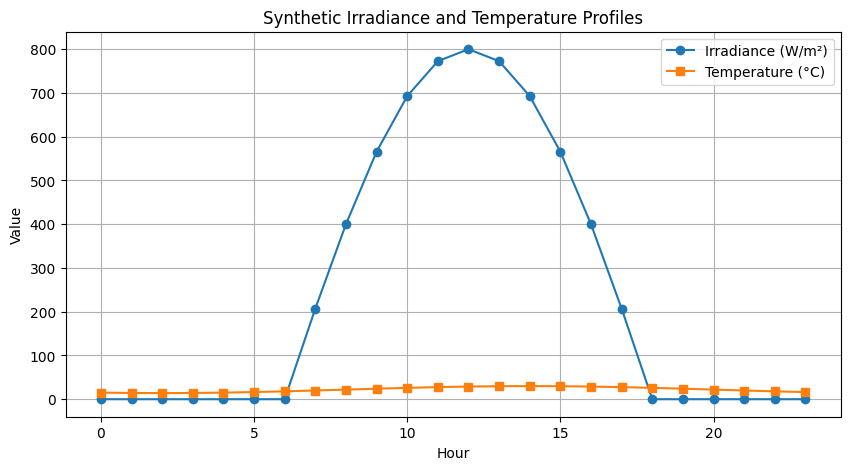

In [30]:
plt.figure(figsize=(10, 5))
plt.plot(df["hour"], df["irradiance"], marker="o", label="Irradiance (W/m²)")
plt.plot(df["hour"], df["temperature"], marker="s", label="Temperature (°C)")
plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Synthetic Irradiance and Temperature Profiles")
plt.legend()
plt.grid(True)
plt.show()

## 3. Estimate PV power using a simplified physical model
A basic PV model is used where power depends on irradiance, panel area, efficiency, and temperature-dependent efficiency correction.

In [31]:
# PV model assumptions
pv_area = 10                 # m²
panel_efficiency_ref = 0.18  # 18% reference efficiency
temp_coeff = -0.004          # efficiency drop per °C above 25°C
ref_temp = 25                # reference temperature (°C)

# Temperature-corrected efficiency
df["efficiency"] = panel_efficiency_ref * (1 + temp_coeff * (df["temperature"] - ref_temp))

# Prevent unrealistic negative/very small efficiency
df["efficiency"] = df["efficiency"].clip(lower=0.05)

# Estimate PV power output (W)
df["pv_power"] = df["irradiance"] * pv_area * df["efficiency"]

df.head()

,hour,irradiance,temperature,efficiency,pv_power
0,0,0.0,15.071797,0.187148,0.0
1,1,0.0,14.272593,0.187724,0.0
2,2,0.0,14.000000,0.187920,0.0
3,3,0.0,14.272593,0.187724,0.0
4,4,0.0,15.071797,0.187148,0.0


## 4. Visualize estimated PV power output

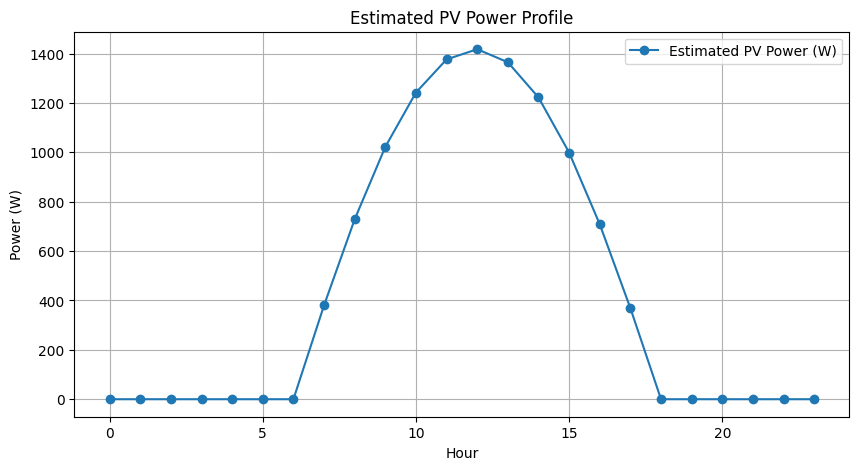

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(df["hour"], df["pv_power"], marker="o", label="Estimated PV Power (W)")
plt.xlabel("Hour")
plt.ylabel("Power (W)")
plt.title("Estimated PV Power Profile")
plt.legend()
plt.grid(True)
plt.show()

## 5. Forecast PV power using linear regression
The regression model uses irradiance and temperature as input features.

In [33]:
# Input features and target
X = df[["irradiance", "temperature"]]
y = df["pv_power"]

# Train linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict PV power
df["predicted_power"] = model.predict(X)

# Evaluate performance
mae = mean_absolute_error(y, df["predicted_power"])
r2 = r2_score(y, df["predicted_power"])

print("Mean Absolute Error (MAE):", round(mae, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 4.77
R² Score: 0.9999


## 6. Compare estimated and predicted PV power

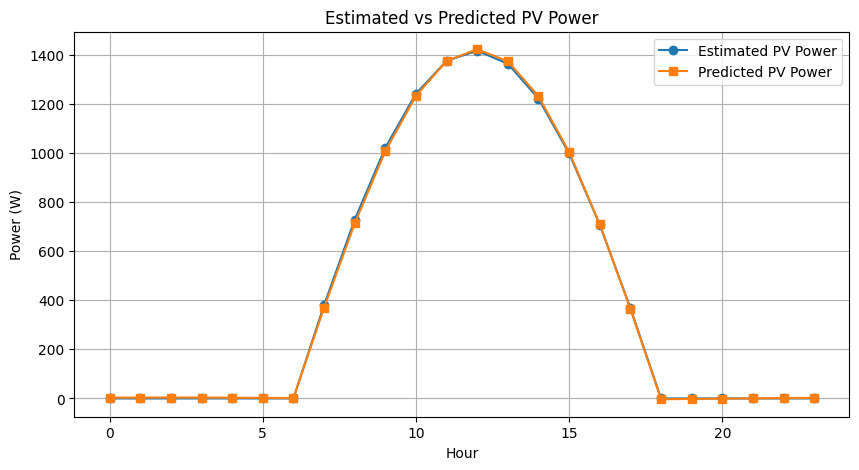

In [34]:
plt.figure(figsize=(10, 5))
plt.plot(df["hour"], df["pv_power"], marker="o", label="Estimated PV Power")
plt.plot(df["hour"], df["predicted_power"], marker="s", label="Predicted PV Power")
plt.xlabel("Hour")
plt.ylabel("Power (W)")
plt.title("Estimated vs Predicted PV Power")
plt.legend()
plt.grid(True)
plt.show()

## 7. Final results table

In [35]:
df.round(2)

,hour,irradiance,temperature,efficiency,pv_power,predicted_power
0,0,0.00,15.07,0.19,0.00,3.12
1,1,0.00,14.27,0.19,0.00,3.58
2,2,0.00,14.00,0.19,0.00,3.74
3,3,0.00,14.27,0.19,0.00,3.58
4,4,0.00,15.07,0.19,0.00,3.12
5,5,0.00,16.34,0.19,0.00,2.39
6,6,0.00,18.00,0.19,0.00,1.44
7,7,207.06,19.93,0.18,380.26,370.05
8,8,400.00,22.00,0.18,728.64,713.38
9,9,565.69,24.07,0.18,1022.02,1008.03


## Results Summary

In [36]:
summary = pd.DataFrame({
    "Metric": ["Mean PV Power", "Max PV Power", "MAE", "R²"],
    "Value": [
        df["pv_power"].mean(),
        df["pv_power"].max(),
        mae,
        r2
    ]
})

summary

,Metric,Value
0,Mean PV Power,451.237577
1,Max PV Power,1417.373549
2,MAE,4.773074
3,R²,0.999868


## Discussion

This simplified workflow illustrates how physics-based photovoltaic modeling can be combined with data-driven methods for performance prediction, which is a common approach in modern renewable energy forecasting systems.

Although the dataset used here is synthetic, the workflow illustrates key steps relevant to real-world photovoltaic performance forecasting, including:

- physics-based estimation of PV power
- temperature-dependent efficiency modeling
- regression-based forecasting

Such hybrid approaches combining physical modeling and data-driven methods are commonly used in modern renewable energy system analysis.